[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter9_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 9: Realised Volatility

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: pen and paper (A1–A8); Part B: computation and inference (B1–B9); Part C: open questions (C1, C3) and the critique of an AI answer (C2).
- Each task has its own section below, with the same number as on the slides; a worked example to follow is named for every proposed task.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
# On Colab, install arch first: !pip install arch
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours (reference lines in black; light bands only for intervals)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Black    = '#000000'
LightGray = '#C5D2E8'
MODEL_COL = {'logHAR': IDAred, 'HAR': Orange, 'GARCH-t': MainBlue, 'EWMA': Purple, 'RW': Forest}
MODEL_LABEL = {'logHAR': 'log-HAR', 'HAR': 'HAR', 'GARCH-t': 'GARCH(1,1)-t', 'EWMA': 'EWMA', 'RW': "Yesterday's RV"}

HERE = '.'
SEED = 42
OOS_SPY = '2022-01-03'
OOS_BTC = '2025-03-01'
B_BOOT = 2000
C_START = '2025-03-01'


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=0.0):
    """A single legend for a multi-panel figure, below the figure."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels:
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def ann(v, ppy):
    """Annualised volatility (%) from a daily variance (%^2)."""
    return np.sqrt(ppy * v)


import tempfile
SAVE_TO_DRIVE = globals().get('SAVE_TO_DRIVE', False)
OUT_DIR = globals().get('OUT_DIR', '.')
# intermediate tables: your Drive folder if SAVE_TO_DRIVE is True, otherwise a temporary folder
HERE = OUT_DIR if SAVE_TO_DRIVE else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it (PDF and PNG) in OUT_DIR."""
    if SAVE_TO_DRIVE:
        plt.savefig(os.path.join(OUT_DIR, name + '.pdf'), bbox_inches='tight', transparent=True)
        plt.savefig(os.path.join(OUT_DIR, name + '.png'), bbox_inches='tight', dpi=150, transparent=True)
    plt.show()
    plt.close()

## Realised measures, HAR and forecast evaluation

- Realised measures: realised variance, bipower variation, realised and tripower quarticity, the confidence interval for integrated variance and the ratio jump test (`rv`, `bv`, `rq`, `tq`, `rv_ci`, `jump_test`).
- Sampling and microstructure noise: sparse and subsampled RV, the signature plot, two-scale RV, the realised kernel and the noise variance (`sparse_rv`, `subsampled_rv`, `signature`, `tsrv`, `realized_kernel`, `noise_var`).
- HAR-RV with Newey–West standard errors and expanding-window out-of-sample forecasts (`har_design`, `ols_nw`, `har_fit`, `har_expanding`, `har_weights`).
- Forecast evaluation: GARCH(1,1) and EWMA benchmarks, QLIKE and MSE losses, Diebold–Mariano and Mincer–Zarnowitz tests and the moving-block bootstrap (`garch_forecasts`, `ewma_forecasts`, `qlike`, `mse`, `dm_test`, `mz_test`, `block_bootstrap`).

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gamma as G

MU1 = np.sqrt(2 / np.pi)                              # E|Z|, Z ~ N(0,1)
MU43 = 2 ** (2 / 3) * G(7 / 6) / G(1 / 2)             # E|Z|^{4/3}


# =============================================================================
# REALISED ESTIMATORS (one value per day)
# =============================================================================
def rv(R):
    """Realised variance: sum of squared intraday returns."""
    return (R ** 2).sum(axis=1, min_count=1)


def nret(R):
    """Number of intraday returns of each day."""
    return R.notna().sum(axis=1)


def bv(R):
    """Bipower variation (Barndorff-Nielsen and Shephard): robust to jumps."""
    a = R.abs().values
    M = nret(R).values
    s = np.nansum(a[:, 1:] * a[:, :-1], axis=1)
    return pd.Series(MU1 ** -2 * M / (M - 1) * s, index=R.index)


def tq(R):
    """Tripower quarticity: estimates integrated quarticity, robust to jumps."""
    a = R.abs().values ** (4 / 3)
    M = nret(R).values
    s = np.nansum(a[:, 2:] * a[:, 1:-1] * a[:, :-2], axis=1)
    return pd.Series(M * MU43 ** -3 * M / (M - 2) * s, index=R.index)


def rq(R):
    """Realised quarticity (M/3) * sum r^4."""
    return nret(R) / 3 * (R ** 4).sum(axis=1)


def rv_ci(R, level=0.95):
    """Asymptotic confidence interval for integrated variance, built on the log scale."""
    v = rv(R)
    se_log = np.sqrt(2 / 3 * (R ** 4).sum(axis=1)) / v
    z = stats.norm.ppf(0.5 + level / 2)
    return v * np.exp(-z * se_log), v * np.exp(z * se_log)


def jump_test(R, alpha=0.001):
    """Ratio jump test (RV - BV)/RV (Huang and Tauchen); significant jump if z > z_{1-alpha}."""
    v, b, t = rv(R), bv(R), tq(R)
    M = nret(R)
    theta = MU1 ** -4 + 2 * MU1 ** -2 - 5
    z = ((v - b) / v) / np.sqrt(theta / M * np.maximum(1, t / b ** 2))
    jump = z > stats.norm.ppf(1 - alpha)
    J = np.where(jump, np.maximum(v - b, 0), 0.0)
    return pd.DataFrame({'rv': v, 'bv': b, 'tq': t, 'z': z, 'jump': jump, 'J': J, 'C': v - J})


# =============================================================================
# MICROSTRUCTURE NOISE
# =============================================================================
def sparse_points(P, k, offset=0):
    """Prices at every k-th grid point, starting at offset; the open and the close are kept."""
    out = {}
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)
    cols = np.arange(P.shape[1])
    X = P.values
    for i, day in enumerate(P.index):
        idx = cols[(cols >= offset) & ((cols - offset) % k == 0) & (cols <= last[i])]
        idx = np.unique(np.r_[0, idx, last[i]])
        out[day] = np.log(X[i, idx])
    return out


def sparse_rv(P, k, offset=0):
    """Realised variance from k x 5-minute returns (a single grid)."""
    pts = sparse_points(P, k, offset)
    return pd.Series({d: np.sum((100 * np.diff(x)) ** 2) for d, x in pts.items()})


def subsampled_rv(P, k):
    """Average of the realised variances on the k shifted grids (sparse sampling without discarding data)."""
    return pd.concat([sparse_rv(P, k, o) for o in range(k)], axis=1).mean(axis=1)


def signature(P, ks, scale):
    """Signature plot: mean annualised volatility (%) as a function of the sampling interval."""
    return pd.DataFrame({
        'sparse': [np.sqrt(scale * sparse_rv(P, k).mean()) for k in ks],
        'subsampled': [np.sqrt(scale * subsampled_rv(P, k).mean()) for k in ks]}, index=list(ks))


def tsrv(P, K=6, adjust=False):
    """Two-scale realised variance (Zhang, Mykland and Ait-Sahalia): average over K grids minus the noise correction.
    Grilele pastreaza deschiderea si inchiderea, deci nbar = numarul mediu EFECTIV de randamente pe grila
    (the noise bias of the average is 2 nbar omega^2); adjust=True divides by 1 - nbar/n (small samples)."""
    R = 100 * np.log(P).diff(axis=1).iloc[:, 1:]
    n = nret(R)
    nbar = pd.concat([pd.Series({d: len(x) - 1 for d, x in sparse_points(P, K, o).items()}) for o in range(K)],
                     axis=1).mean(axis=1)
    ts = subsampled_rv(P, K) - nbar / n * rv(R)
    return ts / (1 - nbar / n) if adjust else ts


def noise_var(R):
    """Noise variance: omega^2 = -cov(r_i, r_{i-1}) and the upper bound RV/(2n), averaged over days."""
    X = R.values
    cov1 = np.nanmean(X[:, 1:] * X[:, :-1])
    return {'omega2_cov': max(-cov1, 0.0), 'omega2_rv': float((rv(R) / (2 * nret(R))).mean()),
            'rho1': float(pd.Series(X[:, 1:].ravel()).corr(pd.Series(X[:, :-1].ravel())))}


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def realized_kernel(R, P, c=3.5134):
    """Parzen realised kernel (Barndorff-Nielsen, Hansen, Lunde and Shephard); bandwidth H from their rule."""
    out, Hs = {}, {}
    iv20 = sparse_rv(P, 4)                                  # variance on the 20-minute grid, for xi
    for i, day in enumerate(R.index):
        r = R.iloc[i].dropna().values
        n = len(r)
        om2 = np.sum(r ** 2) / (2 * n)
        xi2 = om2 / max(iv20[day], 1e-12)
        H = max(1, int(np.ceil(c * xi2 ** 0.4 * n ** 0.6)))
        g = [np.sum(r[h:] * r[:n - h]) for h in range(H + 1)]
        out[day] = g[0] + 2 * sum(parzen(h / (H + 1)) * g[h] for h in range(1, H + 1))
        Hs[day] = H
    return pd.Series(out), pd.Series(Hs)


# =============================================================================
# HAR-RV
# =============================================================================
def har_design(v, calendar=False):
    """HAR regressors: daily, weekly and monthly components (5 and 22 trading days;
    for crypto, calendar days: 7 and 30 days, with at least 5 and 20 observations)."""
    if calendar:
        full = v.asfreq('D')
        d = full.shift(1)
        w = full.rolling(7, min_periods=5).mean().shift(1)
        m = full.rolling(30, min_periods=20).mean().shift(1)
        X = pd.DataFrame({'d': d, 'w': w, 'm': m}).reindex(v.index)
    else:
        X = pd.DataFrame({'d': v.shift(1), 'w': v.rolling(5).mean().shift(1), 'm': v.rolling(22).mean().shift(1)})
    return X


def nw_lags(T):
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def ols_nw(y, X, lags=None):
    """OLS with intercept and Newey-West (HAC) standard errors."""
    Xc = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    T, k = Xc.shape
    XtX_inv = np.linalg.inv(Xc.T @ Xc)
    b = XtX_inv @ Xc.T @ y
    e = y - Xc @ b
    L = nw_lags(T) if lags is None else lags
    u = Xc * e[:, None]
    S = u.T @ u
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        g = u[l:].T @ u[:-l]
        S += w * (g + g.T)
    V = XtX_inv @ S @ XtX_inv
    r2 = 1 - e @ e / np.sum((y - y.mean()) ** 2)
    return {'b': b, 'se': np.sqrt(np.diag(V)), 'V': V, 'r2': r2, 'resid': e, 'T': T, 'lags': L}


def har_fit(v, calendar=False, log=False, jumps=None):
    """HAR-RV on the full sample; log=True: HAR on log RV; jumps: jump component as an extra regressor."""
    X = har_design(np.log(v) if log else v, calendar)
    if jumps is not None:
        X['J'] = jumps.shift(1).reindex(X.index) if not calendar else jumps.asfreq('D').shift(1).reindex(X.index)
    y = np.log(v) if log else v
    ok = X.notna().all(axis=1)
    return ols_nw(y[ok], X[ok]), X, ok


def har_expanding(v, start, calendar=False, log=False, min_obs=100):
    """HAR forecasts for day t, re-estimated daily on all observations before t (expanding window)."""
    y = np.log(v) if log else v
    X = har_design(y, calendar)
    ok = X.notna().all(axis=1)
    Xv, yv = X.values, y.values
    Xc = np.column_stack([np.ones(len(X)), Xv])
    out = {}
    for t in np.where((v.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        if len(tr) < min_obs:
            continue
        b, *_ = np.linalg.lstsq(Xc[tr], yv[tr], rcond=None)
        f = Xc[t] @ b
        if log:
            s2 = np.var(yv[tr] - Xc[tr] @ b)
            f = np.exp(f + s2 / 2)
        out[v.index[t]] = f
    return pd.Series(out)


def har_weights(b, n=30):
    """Implied HAR weights on each lag 1..n (HAR = restricted AR(22))."""
    w = np.zeros(n)
    w[0] += b[1]
    w[:5] += b[2] / 5
    w[:22] += b[3] / 22
    return w


# =============================================================================
# BENCHMARKS: GARCH AND EWMA ON DAILY RETURNS
# =============================================================================
def garch_forecasts(r, dates, refit=21, dist='t'):
    """Forecast variance for each day in dates with GARCH(1,1), re-estimated every `refit` days
    on all earlier data; between re-estimations the parameters stay fixed and the variance is updated daily."""
    from arch import arch_model
    dates = pd.DatetimeIndex(dates)
    pos = r.index.get_indexer(dates)
    out = pd.Series(np.nan, index=dates)
    for i0 in range(0, len(dates), refit):
        blk = dates[i0:i0 + refit]
        p0 = pos[i0]
        fit = arch_model(r.iloc[:p0], mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
        fixed = arch_model(r.iloc[:pos[min(i0 + refit, len(dates)) - 1] + 1], mean='Constant', vol='GARCH', p=1, q=1,
                           dist=dist).fix(fit.params)
        out[blk] = (fixed.conditional_volatility ** 2).reindex(blk).values
    return out


def ewma_forecasts(r, lam=0.94, burn=250):
    """RiskMetrics: sigma^2_t = lambda sigma^2_{t-1} + (1 - lambda) r^2_{t-1}."""
    x = r.values
    s = np.empty(len(x))
    s[0] = np.var(x[:burn])
    for t in range(1, len(x)):
        s[t] = lam * s[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s, index=r.index)


# =============================================================================
# FORECAST EVALUATION
# =============================================================================
def qlike(v, f):
    """QLIKE: v/f - log(v/f) - 1 (robust to noise in the proxy, Patton 2011)."""
    return v / f - np.log(v / f) - 1


def mse(v, f):
    return (v - f) ** 2


def dm_test(l1, l2):
    """Diebold-Mariano: d = l1 - l2; t = mean(d)/se_NW; d < 0 => model 1 has the smaller loss."""
    d = (l1 - l2).dropna().values
    res = ols_nw(d, np.empty((len(d), 0)))
    t = res['b'][0] / res['se'][0]
    return {'mean_diff': float(d.mean()), 't': float(t), 'p': float(2 * stats.norm.sf(abs(t))), 'T': len(d)}


def mz_test(v, f):
    """Mincer-Zarnowitz regression v = a + b f + e; joint Wald test of (a, b) = (0, 1) with the NW covariance."""
    res = ols_nw(v.values, f.values[:, None])
    dlt = res['b'] - np.array([0.0, 1.0])
    W = float(dlt @ np.linalg.inv(res['V']) @ dlt)
    return {'a': res['b'][0], 'b': res['b'][1], 'se_a': res['se'][0], 'se_b': res['se'][1], 'r2': res['r2'],
            'wald': W, 'p': float(stats.chi2.sf(W, 2))}


def block_bootstrap(x, stat, block=20, B=2000, seed=42):
    """Moving-block bootstrap (Kunsch): distribution of `stat` on series rebuilt from blocks."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]
        out[b] = stat(x[idx])
    return out


def block_bootstrap_blocks(x, stat, block=60, B=300, seed=42):
    """Moving-block bootstrap that keeps the blocks separate: `stat` receives a matrix (blocks x length),
    so increments are computed only within each block (no artificial jumps at the joins)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        out[b] = stat(x[starts[:, None] + np.arange(block)[None, :]])
    return out


# =============================================================================
# ROUGH VOLATILITY
# =============================================================================

## Data

- SPY: 5-minute bars of the regular US session (09:30–16:00 New York time), October 2020 – September 2026.
- Bitcoin: 5-minute bars, 24-hour UTC days with at least 95% of the bars, September 2024 – September 2026.
- Daily closes of SPY (adjusted) and Bitcoin, and the VIX index.
- Returns in %, daily variances in %²; SPY total daily variance = intraday RV + squared overnight return.

In [ ]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when running inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, price field, label, traded 7 days a week?)
DAILY = {
    'spy': ('SPY.US', 'adjusted_close', 'SPY (S&P 500 ETF)', False),
    'sp500': ('GSPC.INDX', 'close', 'S&P 500', False),
    'btc': ('BTC-USD.CC', 'close', 'Bitcoin', True),
    'vix': ('VIX.INDX', 'close', 'VIX', False),
}


def read_market(symbol):
    """Daily prices of one course series (local copy if present, otherwise the online copy)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_intraday(symbol):
    """5-minute bars of one course series (UTC time)."""
    fname = f'intraday/{symbol}_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    d = pd.read_csv(src, index_col='datetime_utc', parse_dates=True).sort_index()
    return d[~d.index.duplicated(keep='last')]


def daily_close(name, start=None, end=END):
    """Daily price: no weekend quotes (except crypto) and no days with an unchanged price (indices)."""
    symbol, col, _, all_week = DAILY[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if not all_week:
        s = s[s.index.dayofweek < 5]
    if name in ('sp500', 'vix'):
        s = s[s.diff() != 0]
    return s.rename(name)


def daily_returns(name, start=None, end=END):
    """Daily log returns in %, on the series' own calendar."""
    return (100 * np.log(daily_close(name, start, end)).diff().dropna()).rename(name)


def spy_intraday(end=END):
    """SPY prices in the regular session: day x 79 matrix (09:30 open + 78 bar closes)."""
    d = read_intraday('SPY.US')
    d.index = d.index.tz_localize('UTC').tz_convert('America/New_York')
    d = d[(d.index.second == 0) & (d.index.minute % 5 == 0)]            # drop bars off the 5-minute grid
    mins = d.index.hour * 60 + d.index.minute
    d = d[(mins >= 9 * 60 + 30) & (mins <= 15 * 60 + 55)]               # 09:30-15:55 (drop the stub 16:00 bar)
    d = d.loc[:end + ' 23:59']
    slot = ((d.index.hour * 60 + d.index.minute) - (9 * 60 + 30)) // 5  # 0..77
    day = pd.to_datetime(d.index.date)
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': d['close'].values}).pivot(index='day', columns='slot', values='p')
    first = pd.Series(d['open'].values, index=day)[slot == 0]
    first = first[~first.index.duplicated()]
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P = P[P[0].notna() & P[-1].notna()]
    P.columns = range(P.shape[1])                                        # 0 = open, 1..78 = bar closes
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)                # last available bar of the day
    F = P.ffill(axis=1)                                                  # missing bars inside the day: previous price
    F = F.where(np.arange(P.shape[1])[None, :] <= last[:, None])         # after the close of short days: NaN
    return F


def btc_intraday(end=END, min_share=0.95):
    """Bitcoin prices on UTC days: day x 289 matrix (00:00 open + 288 bar closes)."""
    d = read_intraday('BTC-USD.CC')
    d = d[d['close'].notna() & (d['close'] > 0)].loc[:end + ' 23:59']
    g = d.resample('5min', label='left', closed='left').agg({'open': 'first', 'close': 'last'})
    have = g['close'].notna()
    day = pd.to_datetime(g.index.date)
    n = have.groupby(day).sum()
    keep = n[n >= min_share * 288].index
    g = g[day.isin(keep)]
    day = pd.to_datetime(g.index.date)
    slot = (g.index.hour * 60 + g.index.minute) // 5
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': g['close'].values}).pivot(index='day', columns='slot', values='p')
    close = close.ffill(axis=1)                                          # short gaps: last known price
    op = pd.DataFrame({'day': day, 'slot': slot, 'p': g['open'].values}).pivot(index='day', columns='slot', values='p')
    first = op.bfill(axis=1)[0].fillna(close[0])
    close = close.bfill(axis=1)                                          # day that starts with a gap
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P.columns = range(P.shape[1])
    return P


def intraday_returns(P):
    """Intraday log returns in %: column j = interval (j-1, j]; NaN after the close of short days."""
    return 100 * np.log(P).diff(axis=1).iloc[:, 1:]


def spy_overnight(P):
    """Overnight return (%): adjusted daily return minus the open-to-close return of the day."""
    oc = 100 * np.log(P.ffill(axis=1).iloc[:, -1] / P[0])
    cc = daily_returns('spy').reindex(P.index)
    return (cc - oc).rename('overnight'), oc.rename('open_close'), cc.rename('close_close')


# ---- data used in all analyses
P_SPY = spy_intraday()
R_SPY = intraday_returns(P_SPY)
ON, OC, CC = spy_overnight(P_SPY)
RV_SPY = rv(R_SPY)                       # intraday realised variance (%^2)
RVT_SPY = RV_SPY + ON ** 2                 # total daily variance: intraday + squared overnight return
P_BTC = btc_intraday()
R_BTC = intraday_returns(P_BTC)
RV_BTC = rv(R_BTC)
D_SPY = daily_returns('spy', start='2000-01-01')
D_BTC = daily_returns('btc', start='2014-09-17')
print('SPY:', RV_SPY.index[0].date(), '->', RV_SPY.index[-1].date(), len(RV_SPY), 'days')
print('Bitcoin:', RV_BTC.index[0].date(), '->', RV_BTC.index[-1].date(), len(RV_BTC), 'days')

## Seminar functions

- The returns of A1.

In [ ]:
A1_R = np.array([0.08, -0.15, 0.03, 0.1, -0.04, 0.12])

## Out-of-sample forecasts (Chapter 9)

- One-day forecasts of log-HAR, HAR, GARCH(1,1)-t, EWMA and yesterday's RV, used in A8, B5, B9 and C1.

In [ ]:
def oos_forecasts(v, r, start, calendar):
    """Next-day forecasts: HAR, log-HAR (expanding window), GARCH(1,1)-t and EWMA on daily returns, yesterday's RV."""
    idx = v.loc[start:].index
    F = pd.DataFrame({
        'logHAR': har_expanding(v, start, calendar=calendar, log=True),
        'HAR': har_expanding(v, start, calendar=calendar),
        'GARCH-t': garch_forecasts(r, idx),
        'EWMA': ewma_forecasts(r).reindex(idx),
        'RW': (v.asfreq('D').shift(1).reindex(idx) if calendar else v.shift(1).reindex(idx))}).dropna()
    return F, v.reindex(F.index)


F, y = oos_forecasts(RVT_SPY, D_SPY, OOS_SPY, False)
Fb, yb = oos_forecasts(RV_BTC, D_BTC, OOS_BTC, True)
F.assign(proxy=y).to_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'))
Fb.assign(proxy=yb).to_csv(os.path.join(HERE, 'ch9_forecasts_btc.csv'))

## Part A — pen and paper

### A1. Precision of realised variance [Solved]

- Constant volatility: E[RV] = σ², Var(RV) = 2σ⁴/M, RQ = (M/3)Σr⁴ unbiased for IQ; delta-method CI for IV on the log scale. Check by simulation.

In [8]:
rng = np.random.default_rng(42)
M, sigma2 = 78, 1.0
r = np.sqrt(sigma2 / M) * rng.standard_normal((100_000, M))
rv_s = (r ** 2).sum(axis=1)
rq_s = M / 3 * (r ** 4).sum(axis=1)
print('E[RV]', rv_s.mean().round(4), ' Var(RV)', rv_s.var().round(4), ' 2/M', round(2 / M, 4), ' E[RQ]', rq_s.mean().round(4))
se_log = np.sqrt(2 * rq_s / M) / rv_s
cover = np.mean((np.log(rv_s) - 1.96 * se_log <= 0) & (0 <= np.log(rv_s) + 1.96 * se_log))
print('coverage of the log-scale 95% CI:', cover.round(3), ' CI factor', np.exp([-1.96 * np.sqrt(2 / M), 1.96 * np.sqrt(2 / M)]).round(2))

E[RV] 0.9996  Var(RV) 0.0256  2/M 0.0256  E[RQ] 1.0
coverage of the log-scale 95% CI: 0.941  CI factor [0.73 1.37]


### A2. Six returns and one jump [Proposed]

- Returns 0.08, −0.15, 0.03, 0.10, −0.04, −0.90 (%): RV, BV, the jump part and its share, the ratio statistic with the max(1, TQ/BV²) floor, the decision at 0.1% and the largest attainable z with M = 6.
- A2 extended: why BV ignores a jump in an interior interval (the jump enters two products of order Δ^(1/2)).
- Worked example to follow: A1.

In [ ]:
# Your code here


### A3. Noise bias and the optimal frequency [Solved]

- Derive E[RV] = IV + 2nω², cov(r_i, r_{i−1}) = −ω², n* = (IQ/(4ω⁴))^(1/3); IV = 1 %², ω = 0.01%.

In [10]:
def a3_noise(iv=1.0, omega=0.01):
    """Noise bias: E[RV] = IV + 2 n omega^2; optimal frequency n* = (IQ / (4 omega^4))^(1/3) with IQ = IV^2."""
    rows = {n: {'bias': 2 * n * omega ** 2, 'erv': iv + 2 * n * omega ** 2} for n in (78, 390, 23400)}
    nstar = (iv ** 2 / (4 * omega ** 4)) ** (1 / 3)
    return {'rows': rows, 'nstar': nstar, 'secs': 23400 / nstar, 'omega2': omega ** 2}


a3_noise()

{'rows': {78: {'bias': 0.015600000000000001, 'erv': 1.0156},
  390: {'bias': 0.078, 'erv': 1.078},
  23400: {'bias': 4.680000000000001, 'erv': 5.680000000000001}},
 'nstar': 292.4017738212865,
 'secs': 80.02687430446944,
 'omega2': 0.0001}

### A4. Two-scale RV and its rate [Proposed]

- ω = 0.03%, IV = 1 %², IQ = IV² = 1 (constant volatility): bias, n*; TSRV with n = 390 one-minute returns and K = 5 shifted 5-minute grids, from RV_all = 1.70 and RV_avg = 1.10; why the error is of order n^(−1/6).
- Worked example to follow: A3.

In [ ]:
# Your code here


### A5. HAR as a restricted AR(22) [Solved]

- Implied AR(22) coefficients, the 19 × 23 restriction matrix, the Wald statistic; rounded SPY β = (−0.08, 0.36, 0.34, 0.17).

In [12]:
def a5_har(b=(-0.08, 0.36, 0.34, 0.17), d=np.log(2.0), w=np.log(1.2), m=np.log(0.9)):
    """log-HAR forecast for tomorrow; implied lag weights; persistence."""
    lf = b[0] + b[1] * d + b[2] * w + b[3] * m
    return {'lf': lf, 'f': np.exp(lf), 'w1': b[1] + b[2] / 5 + b[3] / 22, 'w2': b[2] / 5 + b[3] / 22, 'w6': b[3] / 22,
            'pers': b[1] + b[2] + b[3], 'geo_mean': np.exp(b[0] / (1 - sum(b[1:]))), 'd': d, 'w': w, 'm': m}


Rm = []
for k in list(range(2, 5)) + list(range(6, 22)):
    row = np.zeros(23); row[k] = 1; row[k + 1] = -1; Rm.append(row)
print('restrictions:', len(Rm))
a5_har()

restrictions: 19


{'lf': np.float64(0.2136110266496944),
 'f': np.float64(1.2381409572794742),
 'w1': 0.43572727272727274,
 'w2': 0.07572727272727273,
 'w6': 0.007727272727272728,
 'pers': 0.87,
 'geo_mean': np.float64(0.5404329964865341),
 'd': np.float64(0.6931471805599453),
 'w': np.float64(0.1823215567939546),
 'm': np.float64(-0.10536051565782628)}

### A6. Which loss ranks variance forecasts? [Solved]

- QLIKE is minimised at the conditional variance, and the ranking of two forecasts is the same with the proxy or with IV; QLIKE and variance MSE for F = 0.5 and F = 2 when the true variance is 1.
- A6 extended: MSE on volatility, (√RV − √F)², is minimised at (E√RV)²; F*/IV for M = 1, 6, 78.

In [13]:
def ex_a6_jensen():
    """A6: minimiser of the MSE on volatility with a proxy RV = IV chi2_M / M: F* = IV (E sqrt(chi2_M/M))^2."""
    from scipy.special import gammaln
    out = {}
    for m in (1, 6, 78):
        out[str(m)] = float(2 / m * np.exp(2 * (gammaln((m + 1) / 2) - gammaln(m / 2))))
    return out


def a6_losses():
    """QLIKE and MSE for two forecasts over three days."""
    v = np.array([0.8, 1.5, 0.6])
    fa = np.array([1.0, 1.0, 1.0])
    fb = np.array([0.6, 1.6, 0.4])
    out = {}
    for k, f in [('A', fa), ('B', fb)]:
        q = v / f - np.log(v / f) - 1
        e = (v - f) ** 2
        out[k] = {'q': list(q), 'qm': q.mean(), 'e': list(e), 'em': e.mean()}
    # forecast 2 times too small vs 2 times too large (v = 1)
    out['under'] = 1 / 0.5 - np.log(1 / 0.5) - 1
    out['over'] = 1 / 2.0 - np.log(1 / 2.0) - 1
    out['under_mse'] = (1 - 0.5) ** 2
    out['over_mse'] = (1 - 2.0) ** 2
    return out


for m_, v_ in ex_a6_jensen().items():
    print(f'A6 extended: M = {m_}, F*/IV = {v_:.3f}')
a6_losses()

A6 extended: M = 1, F*/IV = 0.637
A6 extended: M = 6, F*/IV = 0.920
A6 extended: M = 78, F*/IV = 0.994


{'A': {'q': [np.float64(0.023143551314209754),
   np.float64(0.09453489189183562),
   np.float64(0.11082562376599059)],
  'qm': np.float64(0.07616802232401199),
  'e': [np.float64(0.03999999999999998),
   np.float64(0.25),
   np.float64(0.16000000000000003)],
  'em': np.float64(0.15)},
 'B': {'q': [np.float64(0.04565126088155247),
   np.float64(0.002038521137571081),
   np.float64(0.09453489189183562)],
  'qm': np.float64(0.047408224636986386),
  'e': [np.float64(0.04000000000000003),
   np.float64(0.010000000000000018),
   np.float64(0.03999999999999998)],
  'em': np.float64(0.03000000000000001)},
 'under': np.float64(0.3068528194400546),
 'over': np.float64(0.1931471805599454),
 'under_mse': 0.25,
 'over_mse': 1.0}

### A7. Attenuation in HAR and the case for HARQ [Proposed]

- RV = IV + u with Var(u) = 2IQ/M: plim of the OLS slope; the weight on RV falls with IQ (HARQ); an instrumental-variables fix.
- Worked example to follow: A5.

In [ ]:
# Your code here


### A8. Accuracy versus calibration [Proposed]

- Is GARCH less accurate than log-HAR, biased, or both? The Diebold–Mariano t for equal accuracy; separate t-tests of a = 0 and b = 1 in the Mincer–Zarnowitz regression; the joint Wald test with the full HAC covariance of (â, b̂) and the 95% confidence ellipse.
- Worked example to follow: A5 (Wald statistic) and A6.

In [ ]:
# Your code here


## Part B — computation and inference

### B1. Jumps in SPY [Solved]

- Ratio statistic for every day; rejections at 5%, 1%, 0.1% vs expected; time of the largest 5-minute return on jump days.
- Interpretation: do the jump times point to scheduled news?

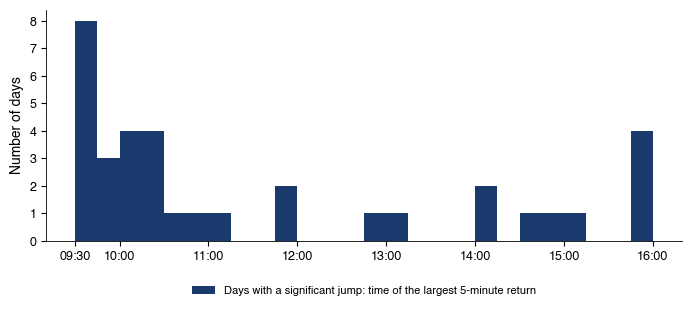

{'N': 1489,
 'n5': 235,
 'share5': 0.15782404298186703,
 'exp5': 74.45,
 'n1': 110,
 'share1': 0.07387508394895903,
 'exp1': 14.89,
 'n0_1': 35,
 'share0_1': 0.02350570852921424,
 'exp0_1': 1.489,
 'at10': 0.05714285714285714,
 'at14': 0.05714285714285714,
 'n_jump': 35,
 'top': [{'date': '2021-08-27',
   'z': 5.218990969338793,
   'jshare': 0.49309151100370663,
   'time': '10:05'},
  {'date': '2022-01-03',
   'z': 5.213766014936756,
   'jshare': 0.46238027303735096,
   'time': '09:50'},
  {'date': '2025-08-25',
   'z': 4.771238432226234,
   'jshare': 0.4215899387016839,
   'time': '16:00'}],
 'jshare': 0.028357370498370525,
 'z_mean': 0.49603864695663646,
 'z_sd': 1.1431418238917002}

In [16]:
def b1_spy_jumps():
    """Jump test on SPY at three levels; time of the largest return on jump days."""
    j = jump_test(R_SPY)
    out = {'N': int(len(j))}
    for a, tag in [(0.05, '5'), (0.01, '1'), (0.001, '0_1')]:
        k = int((j['z'] > stats.norm.ppf(1 - a)).sum())
        out[f'n{tag}'] = k
        out[f'share{tag}'] = k / len(j)
        out[f'exp{tag}'] = a * len(j)
    jd = j[j['jump']].index
    slot = R_SPY.loc[jd].abs().idxmax(axis=1).astype(int)          # column 1..78 = interval ending at 09:30 + 5*col
    end = pd.Timestamp('2000-01-01 09:30') + pd.to_timedelta(5 * slot.values, unit='min')
    hours = pd.Series([t.strftime('%H:%M') for t in end], index=jd)
    at10 = float(np.mean([(t.hour == 10 and t.minute <= 5) for t in end]))
    at14 = float(np.mean([(t.hour == 14 and t.minute <= 5) or (t.hour == 14 and t.minute == 0) for t in end]))
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    mins = np.array([(t.hour - 9) * 60 + t.minute - 30 for t in end])
    ax.hist(mins, bins=np.arange(0, 391, 15), color=MainBlue, label='Days with a significant jump: time of the largest 5-minute return')
    ax.set_xticks([0, 30, 90, 150, 210, 270, 330, 390])
    ax.set_xticklabels(['09:30', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00'])
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch9_sem_jump_times')
    top = j.sort_values('z', ascending=False).head(3)
    out.update({'at10': at10, 'at14': at14, 'n_jump': int(len(jd)),
                'top': [{'date': str(d.date()), 'z': float(r['z']), 'jshare': float(r['J'] / r['rv']),
                         'time': hours[d]} for d, r in top.iterrows()],
                'jshare': float(j['J'].sum() / j['rv'].sum()), 'z_mean': float(j['z'].mean()), 'z_sd': float(j['z'].std())})
    return out


b1_spy_jumps()

#### B1 extended: multiplicity and intraday seasonality [Solved]

- Benjamini–Hochberg and Bonferroni counts; the ratio test on periodicity-corrected returns. The cell also computes the Lee–Mykland intraday test, truncated RV and MedRV (median realised variance) from the lecture appendix.

In [17]:
def bh_count(p, q=0.05):
    """Benjamini-Hochberg: number of rejected hypotheses with the false discovery rate controlled at q."""
    p = np.sort(np.asarray(p))
    n = len(p)
    ok = np.where(p <= q * np.arange(1, n + 1) / n)[0]
    return int(ok[-1] + 1) if len(ok) else 0


def periodicity_sd(R, bv_day):
    """Intraday periodicity factor (SD estimator of Boudt, Croux and Laurent, 2011):
    returns standardised by sqrt(BV_t / M_t), root mean square per interval, normalised to a mean square of 1."""
    M_ = R.notna().sum(axis=1)
    rb = R.div(np.sqrt(bv_day / M_), axis=0)
    sd = np.sqrt((rb ** 2).mean(axis=0))
    return sd / np.sqrt((sd ** 2).mean())


def ex_jump_inference(K=270, alpha_lm=0.01, c_trunc=3.0, varpi=0.49):
    """SPY jumps: FDR (Benjamini-Hochberg), Bonferroni, ratio test on periodicity-adjusted returns,
    Lee-Mykland intraday test (K = 270 for 5 minutes), truncated RV (Mancini) and MedRV (Andersen, Dobrev, Schaumburg)."""
    j = jump_test(R_SPY)
    N = len(j)
    p = stats.norm.sf(j['z'].values)
    out = {'N': N, 'n5': int((p < 0.05).sum()), 'bh5': bh_count(p, 0.05), 'bh1': bh_count(p, 0.01),
           'bonf5': int((p < 0.05 / N).sum()), 'n0_1': int(j['jump'].sum())}
    f = periodicity_sd(R_SPY, j['bv'])
    Rs = R_SPY / f.values[None, :]
    js = jump_test(Rs)
    ps = stats.norm.sf(js['z'].values)
    out.update({'per_n5': int((ps < 0.05).sum()), 'per_n0_1': int(js['jump'].sum()), 'per_bh5': bh_count(ps, 0.05),
                'f_first': float(f.iloc[0]), 'f_min': float(f.min()), 'f_last': float(f.iloc[-1])})
    # Lee-Mykland: L = r / sigma_hat, sigma_hat^2 = mean of the products |r_j||r_{j-1}| over the K-1 previous returns (concatenated series)
    x = Rs.values.ravel()
    day = np.repeat(np.arange(N), Rs.shape[1])
    slot = np.tile(np.arange(Rs.shape[1]), N)
    ok = ~np.isnan(x)
    x, day, slot = x[ok], day[ok], slot[ok]
    prod = np.r_[np.nan, np.abs(x[1:]) * np.abs(x[:-1])]
    bvl = pd.Series(prod).rolling(K - 2).mean().shift(1).values
    L = x / np.sqrt(bvl * np.pi / 2)     # mu_1^{-2} = pi/2: local BV estimates the per-interval variance, so L ~ N(0, 1)
    n = int(np.isfinite(L).sum())
    # Lee and Mykland (2008) divide by local BV without pi/2 and use c = sqrt(2/pi) in C_n, S_n;
    # with the corrected denominator (standardised L) the same thresholds are obtained with c = 1
    c = 1.0
    Cn = np.sqrt(2 * np.log(n)) / c - (np.log(np.pi) + np.log(np.log(n))) / (2 * c * np.sqrt(2 * np.log(n)))
    Sn = 1 / (c * np.sqrt(2 * np.log(n)))
    beta = -np.log(-np.log(1 - alpha_lm))
    hit = np.isfinite(L) & ((np.abs(L) - Cn) / Sn > beta)
    jd = np.unique(day[hit])
    out.update({'lm_K': K, 'lm_n': n, 'lm_crit': float(Cn + Sn * beta), 'lm_hits': int(hit.sum()), 'lm_days': int(len(jd)),
                'lm_open': int((slot[hit] == 0).sum()), 'lm_10': int((slot[hit] == 6).sum()),
                'lm_slots': [int(x) for x in slot[hit]],
                'lm_wed14': int(np.sum(hit & (np.asarray(Rs.index.dayofweek)[day] == 2) & (slot >= 54) & (slot <= 65))),
                'lm_top': {'date': str(Rs.index[day[hit]][np.argmax(np.abs(L[hit]))].date()),
                           'L': float(L[hit][np.argmax(np.abs(L[hit]))])},
                'lm_in_ratio': float(np.mean(j['jump'].values[jd])) if len(jd) else float('nan'),
                'ratio_in_lm': float(np.mean(np.isin(np.where(j['jump'].values)[0], jd)))})
    # truncated RV and MedRV (on raw returns; the threshold accounts for periodicity)
    Mt = R_SPY.notna().sum(axis=1).values
    thr = c_trunc * np.sqrt(j['bv'].values)[:, None] * (1 / Mt[:, None]) ** varpi * f.values[None, :]
    A = R_SPY.values
    trv = np.nansum(np.where(np.abs(A) <= thr, A ** 2, 0.0), axis=1)
    a = np.abs(A)
    med = np.median(np.stack([a[:, :-2], a[:, 1:-1], a[:, 2:]]), axis=0)   # only windows with three observed returns
    medrv = np.pi / (6 - 4 * np.sqrt(3) + np.pi) * Mt / (Mt - 2) * np.nansum(med ** 2, axis=1)
    rvs = j['rv'].values
    out.update({'trv_share': float(1 - trv.sum() / rvs.sum()), 'bv_share': float(1 - j['bv'].sum() / rvs.sum()),
                'medrv_share': float(1 - medrv.sum() / rvs.sum()), 'trunc_days': float(np.mean(trv < rvs)),
                'c_trunc': c_trunc, 'varpi': varpi})
    return out


XJ = ex_jump_inference()
print(f"Days tested: {XJ['N']}; rejections at 5%: {XJ['n5']}; BH at 5%: {XJ['bh5']}, at 1%: {XJ['bh1']}; Bonferroni: {XJ['bonf5']}")
print(f"Periodicity-corrected: {XJ['per_n5']} rejections at 5%, {XJ['per_n0_1']} at 0.1%, {XJ['per_bh5']} under BH 5%; factor at the open {XJ['f_first']:.2f}, minimum {XJ['f_min']:.2f}")
print(f"Lee-Mykland: {XJ['lm_hits']} intraday jumps on {XJ['lm_days']} days; jump share of RV: BV {100 * XJ['bv_share']:.1f}%, MedRV {100 * XJ['medrv_share']:.1f}%, truncated RV {100 * XJ['trv_share']:.1f}%")

Days tested: 1489; rejections at 5%: 235; BH at 5%: 42, at 1%: 9; Bonferroni: 7
Periodicity-corrected: 167 rejections at 5%, 20 at 0.1%, 17 under BH 5%; factor at the open 1.78, minimum 0.73
Lee-Mykland: 169 intraday jumps on 105 days; jump share of RV: BV 6.3%, MedRV 7.2%, truncated RV 12.5%


### B2. Jumps in Bitcoin [Proposed]

- Share of jump days (binomial test), weekends vs weekdays, jump share of variation. Worked example to follow: B1.
- Interpretation: what makes a calm weekend day “jumpy”?

In [ ]:
# Your code here


### B3. Which sampling frequency? [Solved]

- RV at 5, 15, 30, 65 minutes; ratio to the 5-minute RV with a moving-block bootstrap CI; predictive correlation.
- Interpretation: which frequency gives the most useful measurement?

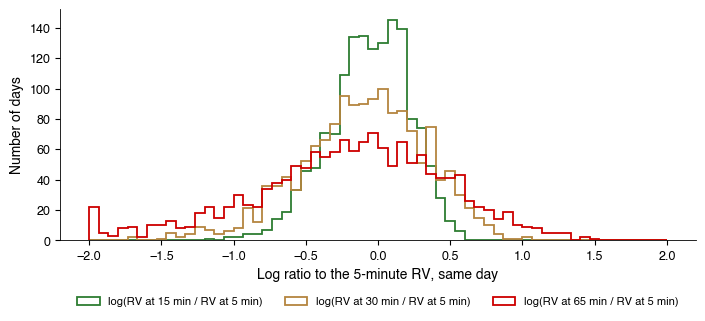

,5,15,30,65
vol,12.929,12.877,12.755,12.757
vol_sub,12.929,12.787,12.769,12.876
ratio,1.000,0.992,0.973,0.974
lo,1.000,0.954,0.933,0.913
hi,1.000,1.035,1.015,1.037
corr_next,0.727,0.709,0.701,0.643
sd_rel,0.000,0.279,0.430,0.681
corr_next_sub,0.727,0.722,0.716,0.701


In [19]:
def b3_frequency():
    """SPY: RV at 5, 15, 30 and 65 minutes; block bootstrap for the ratio of means; predictive power."""
    base = RV_SPY
    out = {}
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    for k, col in [(1, MainBlue), (3, Forest), (6, Amber), (13, IDAred)]:
        v = sparse_rv(P_SPY, k)
        vs = subsampled_rv(P_SPY, k)
        ratio = v.mean() / base.mean()
        boot = block_bootstrap(np.c_[v.values, base.values], lambda x: x[:, 0].mean() / x[:, 1].mean(), 20, B_BOOT, SEED)
        lv = np.log(v)
        nxt = np.log(base).shift(-1)
        c = pd.concat([lv, nxt], axis=1).dropna().corr().iloc[0, 1]
        rel = np.log(v / base)
        out[str(5 * k)] = {'vol': float(ann(v.mean(), 252)), 'vol_sub': float(ann(vs.mean(), 252)), 'ratio': float(ratio),
                           'lo': float(np.percentile(boot, 2.5)), 'hi': float(np.percentile(boot, 97.5)),
                           'corr_next': float(c), 'sd_rel': float(rel.std()),
                           'corr_next_sub': float(pd.concat([np.log(vs), nxt], axis=1).dropna().corr().iloc[0, 1])}
        if k > 1:
            ax.hist(rel.clip(-2, 2), bins=np.linspace(-2, 2, 61), histtype='step', color=col, lw=1.3,
                    label=f'log(RV at {5 * k} min / RV at 5 min)')
    ax.set_xlabel('Log ratio to the 5-minute RV, same day')
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch9_sem_frequency')
    return out


pd.DataFrame(b3_frequency()).round(3)

#### B3 extended: a realised kernel on 5-minute bars [Solved]

- Ratio of the mean realised kernel to the mean 5-minute RV, with the block bootstrap of B3.

In [20]:
def ex_rk_ratio():
    """Realised kernel on 5-minute bars: ratio of means RK/RV with a block bootstrap CI (20-day blocks)."""
    rk, H = realized_kernel(R_SPY, P_SPY)
    rk = rk.reindex(RV_SPY.index)
    boot = block_bootstrap(np.c_[rk.values, RV_SPY.values], lambda x: x[:, 0].mean() / x[:, 1].mean(), 20, B_BOOT, SEED)
    return {'ratio': float(rk.mean() / RV_SPY.mean()), 'lo': float(np.percentile(boot, 2.5)),
            'hi': float(np.percentile(boot, 97.5)), 'H_med': float(H.median())}


XRK = ex_rk_ratio()
print(f"Realised kernel / RV = {XRK['ratio']:.3f}, 95% CI [{XRK['lo']:.3f}, {XRK['hi']:.3f}], median bandwidth H = {XRK['H_med']:.0f}")

Realised kernel / RV = 0.952, 95% CI [0.910, 0.987], median bandwidth H = 7


### B4. Returns standardised by realised volatility [Proposed]

- Kurtosis of r/sd(r) and r/√RV with block bootstrap CIs; Jarque–Bera; share of |z| > 3. Worked example to follow: B3.
- Interpretation: where do the heavy tails come from?

In [ ]:
# Your code here


### B5. log-HAR for SPY with robust inference [Solved]

- OLS and Newey–West standard errors, Wald test β_w = β_m, Ljung–Box on residuals, comparison with AR(1).
- Interpretation: has HAR captured the long memory?

In [22]:
def b5_har_insample():
    """log-HAR on SPY (total variance), OLS with ordinary and Newey-West errors; Wald: beta_w = beta_m; Ljung-Box on residuals."""
    res, X, ok = har_fit(RVT_SPY, log=True)
    y = np.log(RVT_SPY)[ok]
    Xc = np.column_stack([np.ones(ok.sum()), X[ok].values])
    e = res['resid']
    s2 = e @ e / (len(e) - 4)
    se_ols = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
    R = np.array([0, 0, 1, -1.0])
    wald = float((R @ res['b']) ** 2 / (R @ res['V'] @ R))
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(e, lags=[10, 22])
    lb2 = acorr_ljungbox(y.values - y.mean(), lags=[10, 22])
    ar1 = ols_nw(y.values[1:], y.values[:-1, None])
    return {'b': res['b'], 'se_nw': res['se'], 'se_ols': se_ols, 'r2': res['r2'], 'T': res['T'], 'lags': res['lags'],
            'wald_wm': wald, 'p_wm': float(stats.chi2.sf(wald, 1)), 'lb10': float(lb['lb_stat'].iloc[0]), 'lb10_p': float(lb['lb_pvalue'].iloc[0]),
            'lb22': float(lb['lb_stat'].iloc[1]), 'lb22_p': float(lb['lb_pvalue'].iloc[1]), 'lby22': float(lb2['lb_stat'].iloc[1]),
            'pers': float(sum(res['b'][1:])), 'ar1_b': float(ar1['b'][1]), 'ar1_r2': float(ar1['r2']),
            't_nw': list(res['b'] / res['se']), 'ratio_se': list(res['se'] / se_ols)}


b5_har_insample()

{'b': array([-0.07874716,  0.36202234,  0.33691474,  0.16739331]),
 'se_nw': array([0.02658344, 0.03705921, 0.04823207, 0.04395403]),
 'se_ols': array([0.0249223 , 0.03058534, 0.04872425, 0.04560402]),
 'r2': np.float64(0.47030868749339905),
 'T': 1467,
 'lags': 7,
 'wald_wm': 4.171694503127457,
 'p_wm': 0.041104670254420696,
 'lb10': 9.27410603600851,
 'lb10_p': 0.5063025951157142,
 'lb22': 17.50358155328806,
 'lb22_p': 0.7349818195538907,
 'lby22': 4640.86559522571,
 'pers': 0.8663303874336665,
 'ar1_b': 0.6433879429051517,
 'ar1_r2': 0.41318391798209875,
 't_nw': [np.float64(-2.962263498362372),
  np.float64(9.768755668221962),
  np.float64(6.9852848703937545),
  np.float64(3.8083718788554517)],
 'ratio_se': [np.float64(1.0666529666153475),
  np.float64(1.2116658323098388),
  np.float64(0.9898987223521569),
  np.float64(0.9638192492801249)]}

#### B5 extended: the AR(22) test and HARQ [Solved]

- Newey–West Wald test of the 19 HAR restrictions on an AR(22); HARQ on intraday RV and on total variance, with out-of-sample QLIKE; SHAR is also estimated here for B9.

In [23]:
def ex_har_ar22():
    """log-HAR as a restricted AR(22): Wald test (Newey-West) of the 19 linear restrictions."""
    y = np.log(RVT_SPY)
    X = pd.concat({f'l{k}': y.shift(k) for k in range(1, 23)}, axis=1)
    ok = X.notna().all(axis=1)
    res = ols_nw(y[ok].values, X[ok].values)
    Rm = []
    for k in (2, 3, 4):                                   # phi_k = phi_{k+1}, k = 2..4
        r = np.zeros(23); r[k] = 1; r[k + 1] = -1; Rm.append(r)
    for k in range(6, 22):                                # phi_k = phi_{k+1}, k = 6..21
        r = np.zeros(23); r[k] = 1; r[k + 1] = -1; Rm.append(r)
    Rm = np.array(Rm)
    d = Rm @ res['b']
    W = float(d @ np.linalg.solve(Rm @ res['V'] @ Rm.T, d))
    har, Xh, okh = har_fit(RVT_SPY, log=True)
    # same sample for the R^2 comparison
    return {'q': int(Rm.shape[0]), 'wald': W, 'p': float(stats.chi2.sf(W, Rm.shape[0])), 'r2_ar22': float(res['r2']),
            'r2_har': float(har['r2']), 'T': int(res['T']), 'lags': int(res['lags'])}


def _expanding_ols(y, X, start, filt=True):
    """Expanding-window OLS forecasts with the "insanity filter" of Bollerslev, Patton and Quaedvlieg (2016):
    a forecast outside the [min, max] range of the estimation-sample values is replaced by the sample mean."""
    ok = X.notna().all(axis=1) & y.notna()
    Xc = np.column_stack([np.ones(len(X)), X.values])
    f = {}
    for t in np.where((y.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        b, *_ = np.linalg.lstsq(Xc[tr], y.values[tr], rcond=None)
        v = Xc[t] @ b
        if filt and (v < y.values[tr].min() or v > y.values[tr].max()):
            v = y.values[tr].mean()
        f[y.index[t]] = v
    return pd.Series(f)


def ex_harq_shar(start='2022-01-03'):
    """HARQ (Bollerslev, Patton, Quaedvlieg 2016) and SHAR (Patton, Sheppard 2015) on SPY total variance, in levels;
    in sample with Newey-West errors; out-of-sample forecasts; MCS (Hansen, Lunde, Nason 2011) on QLIKE."""
    v = RVT_SPY
    rqd = rq(R_SPY)
    Xh = har_design(v)
    XQ = Xh.copy()
    XQ['dq'] = (np.sqrt(rqd) * v).shift(1)
    okq = XQ.notna().all(axis=1)
    rQ = ols_nw(v[okq].values, XQ[okq].values)
    rH = ols_nw(v[okq].values, Xh[okq].values)
    # semivariances: intraday returns plus the overnight return as one extra return of the day
    A = np.c_[ON.reindex(R_SPY.index).values, R_SPY.values]
    rsp = pd.Series(np.nansum(np.where(A > 0, A ** 2, 0), axis=1), index=R_SPY.index)
    rsn = pd.Series(np.nansum(np.where(A < 0, A ** 2, 0), axis=1), index=R_SPY.index)
    XS = pd.DataFrame({'rsp': rsp.shift(1), 'rsn': rsn.shift(1), 'w': Xh['w'], 'm': Xh['m']})
    oks = XS.notna().all(axis=1)
    rS = ols_nw(v[oks].values, XS[oks].values)
    Rr = np.array([0, 1, -1.0, 0, 0])
    w_pm = float((Rr @ rS['b']) ** 2 / (Rr @ rS['V'] @ Rr))
    F = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'), index_col=0, parse_dates=True)
    fQ = _expanding_ols(v, XQ, start).reindex(F.index)
    fS = _expanding_ols(v, XS, start).reindex(F.index)
    fH = _expanding_ols(v, Xh, start).reindex(F.index)
    y = F['proxy']
    L = pd.DataFrame({m: qlike(y, F[m]) for m in ['logHAR', 'HAR', 'GARCH-t', 'EWMA', 'RW']})
    L['HARQ'] = qlike(y, fQ)
    L['SHAR'] = qlike(y, fS)
    L['HARf'] = qlike(y, fH)
    out = {'harq': {'b': list(rQ['b']), 'se': list(rQ['se']), 'r2': float(rQ['r2']), 'r2_har': float(rH['r2']),
                    'bd_at': {}},
           'shar': {'b': list(rS['b']), 'se': list(rS['se']), 'r2': float(rS['r2']), 'wald_pm': w_pm,
                    'p_pm': float(stats.chi2.sf(w_pm, 1))},
           'qlike': {m: float(L[m].mean()) for m in L}}
    # effective daily slope beta_d + beta_Q sqrt(RQ) at quantiles of sqrt(RQ)
    s = np.sqrt(rqd.reindex(v[okq].index).values)
    for qq in (0.5, 0.99):
        out['harq']['bd_at'][str(qq)] = float(rQ['b'][1] + rQ['b'][4] * np.quantile(s, qq))
    # HARQ on intraday RV (setting of the original paper: RQ and RV from the same returns)
    vi = RV_SPY
    Xi = har_design(vi)
    Xi['dq'] = (np.sqrt(rqd) * vi).shift(1)
    oki = Xi.notna().all(axis=1)
    rI = ols_nw(vi[oki].values, Xi[oki].values)
    si = np.sqrt(rqd.reindex(vi[oki].index).values)
    out['harq_intra'] = {'b': list(rI['b']), 'se': list(rI['se']), 'r2': float(rI['r2']),
                         'bd_at': {str(qq): float(rI['b'][1] + rI['b'][4] * np.quantile(si, qq)) for qq in (0.5, 0.99)},
                         'sq': {str(qq): float(np.quantile(si, qq)) for qq in (0.5, 0.99)}}
    for m in ['HARQ', 'SHAR']:
        for base in ['HARf', 'logHAR']:
            dq = dm_test(L[m], L[base])
            out[f'dm_{m}_{base}'] = {'t': dq['t'], 'p': dq['p']}
    from arch.bootstrap import MCS
    mods = ['logHAR', 'HAR', 'GARCH-t', 'EWMA', 'RW', 'HARQ', 'SHAR']
    mcs = MCS(L[mods].dropna(), size=0.10, reps=10000, block_size=20, method='R', seed=SEED)
    mcs.compute()
    pv = mcs.pvalues['Pvalue']
    out['mcs'] = {'included': [str(m) for m in mcs.included], 'pvalues': {str(k): float(x) for k, x in pv.items()},
                  'T': int(len(L[mods].dropna()))}
    return out


XAR = ex_har_ar22()
print(f"Wald test of the {XAR['q']} HAR restrictions: W = {XAR['wald']:.1f}, p = {XAR['p']:.2f}; R2 AR(22) {XAR['r2_ar22']:.3f} vs HAR {XAR['r2_har']:.3f} ({XAR['T']} days, {XAR['lags']} Newey-West lags)")
XQS = ex_harq_shar()
{k: XQS[k] for k in ['harq', 'harq_intra', 'shar', 'dm_HARQ_HARf']}

Wald test of the 19 HAR restrictions: W = 18.1, p = 0.51; R2 AR(22) 0.477 vs HAR 0.470 (1467 days, 7 Newey-West lags)


{'harq': {'b': [np.float64(0.21692263011055385),
   np.float64(0.5423970880411779),
   np.float64(0.1727284721598824),
   np.float64(0.08778685485855581),
   np.float64(-0.002239674564998293)],
  'se': [np.float64(0.1090175504225918),
   np.float64(0.2818322965200274),
   np.float64(0.12788922865366084),
   np.float64(0.06693068953587104),
   np.float64(0.002403861141258224)],
  'r2': 0.32561856706063297,
  'r2_har': 0.31463386422018225,
  'bd_at': {'0.5': 0.541411330600974, '0.99': 0.5311795390047426}},
 'harq_intra': {'b': [np.float64(0.015298507490634381),
   np.float64(1.135034767395446),
   np.float64(-0.11995259948074292),
   np.float64(0.026335389520845506),
   np.float64(-0.00881937701594493)],
  'se': [np.float64(0.10470783895629994),
   np.float64(0.49363821337282365),
   np.float64(0.2283824737138094),
   np.float64(0.056940210738403316),
   np.float64(0.004180508672566493)],
  'r2': 0.35955697407760245,
  'bd_at': {'0.5': 1.1311530576831075, '0.99': 1.0908623703457663},
  '

### B6. Forecasting the next week [Proposed]

- Direct log-HAR for the 5-day sum vs GARCH(1,1)-t with the h-step formula; QLIKE, MSE, DM, MZ.
- B6 extended: the conditional Giacomini–White test, with both models re-estimated on fixed-length rolling windows.
- Worked example to follow: B5, A6, A8.
- Interpretation: does the advantage of log-HAR survive at a weekly horizon?

In [ ]:
# Your code here


### B7. Do jumps help? The HAR-CJ model [Proposed]

- Continuous and jump components as regressors; in-sample and out-of-sample comparison with log-HAR. Worked example to follow: B5, B1.
- Interpretation: why can a significant coefficient give no forecasting gain?

In [ ]:
# Your code here


### B8. How rough is volatility? [Proposed]

- H for four measures with block bootstrap CIs; simulated Brownian motion with and without noise. Worked example to follow: B3.
- Interpretation: what does measurement error do to the estimate of H?

In [ ]:
# Your code here


### B9. Which models survive? The model confidence set [Proposed]

- Seven models (log-HAR, HAR, GARCH(1,1)-t, EWMA, yesterday's RV, HARQ, SHAR), QLIKE, MCS at 90% with the range statistic and a block bootstrap. Worked example to follow: B5 extended, B6.
- Interpretation: why is the MCS preferable to 21 pairwise DM tests?

In [ ]:
# Your code here


## Part C — open questions and the critique of an AI answer

### C1. Is Bitcoin's volatility more predictable than the S&P 500's? [Proposed]

- Same window, March 2025 – September 2026: log-HAR, GARCH(1,1)-t, yesterday's RV for SPY and Bitcoin.
- R² of log RV on the log forecast, QLIKE gains, CI for the R² difference from a block bootstrap on the same calendar-time blocks for both assets; a weekend dummy for Bitcoin.
- Worked example to follow: B3 (block bootstrap), Chapter 9.

In [ ]:
# Your code here


### C2. Critique an AI answer [Proposed]

- Setting: a student gives an AI assistant a pandas Series `px` of clean, time-sorted SPY trade prices in New York time, 09:30–16:00, several days, in USD (returns are decimal, not %). The answer on the slides contains three conceptual errors.
- Find the three errors; for each give the evidence (a derivation, a check on the output, or a number from the chapter or this seminar) and the correction (formula, code line and the corrected number where one is asked).
- Log each error you found in the format of `AI_ERRORS.md`: request, answer, error, how found, correction. Report a table with one row per error.
- Hints: A3 on the expected RV with noise; what happens between 16:00 and 09:30; plug in RV = 1.0×10⁻⁴ (1 %²).
- Worked example to follow: A3 and B5; a code-reading exercise, no tick data are needed.

In [ ]:
# Your work


### C3. Does machine learning beat HAR for SPY? [Proposed]

- Context: Christensen, Siggaard and Veliyev (2023) find that random forests and neural networks beat HAR once predictors beyond past RV enter, and that the gain grows with the horizon (Chapter 9, case study). Test this on SPY with their sample split and model settings.
- (a) Daily open-to-close RV of SPY from the 5-minute bars (78 returns a day) and three targets: RV the next day, and the average RV over the next 5 and 22 days.
- (b) Two information sets dated t: RV lags only, and RV lags plus VIX, the squared Hang Seng return, SPY momentum and dollar volume, the T-bill rate, economic policy uncertainty and the Aruoba–Diebold–Scotti index, each dated by its release.
- (c) The split of Appendix A.1 of the paper: 1 000 training days, 200 validation days, the rest for the test; no target window crosses a boundary; standardise with training moments only.
- (d) HAR, log-HAR, OLS on all predictors, elastic net, random forest and the neural network NN₂¹⁰ with the settings of the paper (Table A.6).
- (e) Test-set MSE and QLIKE relative to HAR, one-sided DM p-values with HAC errors and the 90% MCS, as in B9.
- Worked example to follow: B5, A6.

In [ ]:
# Your work
